In [7]:
import os
import json
import pickle 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# lenstronomy module import
from lenstronomy.Util import image_util, data_util
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Plots import chain_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Data.psf import PSF
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData

plt.rcParams.update({'font.family': 'serif'})

/home/lauraelina.uronen/.conda/envs/golumlens/lib/python3.10/site-packages/lenstronomy/LensModel/Profiles/epl.py:297: RuntimeWarning: invalid value encountered in divide
  R_omega = Z * hyp2f1(1, t / 2, 2 - t / 2, -(1 - q) / (1 + q) * (Z / Z.conj()))
/local/lauraelina.uronen/ipykernel_3783498/3501049378.py:87: RuntimeWarning: invalid value encountered in log10
  ax[0].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)
/local/lauraelina.uronen/ipykernel_3783498/3501049378.py:167: RuntimeWarning: invalid value encountered in log10
  ax[1].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)
/local/lauraelina.uronen/ipykernel_3783498/3501049378.py:247: RuntimeWarning: invalid value encountered in log10
  ax[2].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)


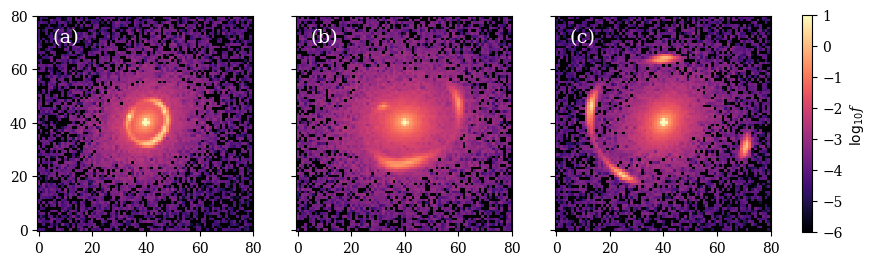

In [81]:
f, ax = plt.subplots(1, 3, figsize=(10, 30), sharex=False, sharey=True)

#########################
# SET UP THE LENS MODEL #
#########################
# lens characteristics
center_x, center_y = 0, 0
# source (EM) characteristics
source_x, source_y = 0.04, -0.01
z_source = 2.0
z_lens = 1.5
lens_model_list = ['EPL', 'SHEAR']
kwargs_epl = {'theta_E': 0.5, 'center_x': center_x, 'center_y': center_y, 'e1': 0., 'e2': 0.1, 'gamma': 2.0}
kwargs_shear = {'gamma1': -0.05, 'gamma2': 0.1}
kwargs_lens = [kwargs_epl, kwargs_shear]
lensModel = LensModel(lens_model_list=lens_model_list, z_source=z_source, z_lens=z_lens)
# lens light
kwargs_lens_light_mag = [{'magnitude': 22, 
                          'R_sersic': .1, 
                          'n_sersic': 4, 
                          'e1': 0, 
                          'e2': 0.1, 
                          'center_x': center_x, 
                          'center_y': center_y}]
# source light
kwargs_source_mag = [{'magnitude': 25, 
                      'R_sersic': 0.02, 
                      'n_sersic': 1, 
                      'e1': -0.1, 
                      'e2': -0.2, 
                      'center_x': source_x, 
                      'center_y': source_y}]

lens_light_model_list = ['SERSIC_ELLIPSE'] 
source_light_model_list = ['SERSIC_ELLIPSE']
lensLightModel = LightModel(light_model_list=lens_light_model_list)
sourceLightModel = LightModel(light_model_list=source_light_model_list)
kwargs_source_light = data_util.magnitude2amplitude(light_model_class= sourceLightModel, 
                                                    kwargs_light_mag = kwargs_source_mag, 
                                                    magnitude_zero_point = 25.75)
kwargs_lens_light = data_util.magnitude2amplitude(light_model_class= lensLightModel, 
                                                  kwargs_light_mag = kwargs_lens_light_mag, 
                                                  magnitude_zero_point = 25.75)
kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],
                'lens_light_model_list': ['SERSIC_ELLIPSE'],
                'source_light_model_list': ['SERSIC_ELLIPSE']}

#####################
# GENERATE THE DATA #
#####################
numPix = 80
deltaPix = 0.067 
shift = numPix * deltaPix / 2
ra_start, dec_start = center_x - shift, center_y - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
fwhm = 0.067 #HST/JWST: 0.067, TMT/ELT: 0.01 in IR
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': deltaPix}
psf = PSF(**kwargs_psf)
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}
imageModel = ImageModel(data_class=pixel_grid, 
                        psf_class=psf, 
                        lens_model_class=lensModel, 
                        source_model_class=sourceLightModel, 
                        lens_light_model_class=lensLightModel, 
                        point_source_class=None, 
                        kwargs_numerics=kwargs_numerics)
imageLens = imageModel.image(kwargs_lens=kwargs_lens,
                              kwargs_source=kwargs_source_light,
                                kwargs_lens_light=kwargs_lens_light,
                                kwargs_ps=None)

#####################
# OBSERVE THE DATA  #
#####################
background_rms = np.sqrt(np.mean((imageLens[0:10,0:10])**2))
exposure_time = 2500
kwargs_data = {'image_data': imageLens, 'background_rms': background_rms, 'exposure_time': exposure_time, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
data_class = ImageData(**kwargs_data)
image_model = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_light, kwargs_lens_light=kwargs_lens_light)
poisson = image_util.add_poisson(image_model, exp_time=exposure_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

ax[0].set_facecolor('black')
ax[0].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)
ax[0].set_xticks([0,20,40,60,80])
ax[0].set_yticks([0,20,40,60,80])
ax[0].tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
ax[0].text(5, 70, '(a)', color='white', fontsize=14)

#########################
# SET UP THE LENS MODEL #
#########################
# lens characteristics
center_x, center_y = 0, 0
# source (EM) characteristics
source_x, source_y = 0.2, -0.1
z_source = 1.5
z_lens = 0.7
lens_model_list = ['EPL', 'SHEAR']
kwargs_epl = {'theta_E': 1.0, 'center_x': center_x, 'center_y': center_y, 'e1': 0.1, 'e2': 0., 'gamma': 2}
kwargs_shear = {'gamma1': 0.1, 'gamma2': 0.2}
kwargs_lens = [kwargs_epl, kwargs_shear]
lensModel = LensModel(lens_model_list=lens_model_list, z_source=z_source, z_lens=z_lens)
# lens light
kwargs_lens_light_mag = [{'magnitude': 22, 
                          'R_sersic': .2, 
                          'n_sersic': 4, 
                          'e1': 0.1, 
                          'e2': 0., 
                          'center_x': center_x, 
                          'center_y': center_y}]
# source light
kwargs_source_mag = [{'magnitude': 26, 
                      'R_sersic': 0.05, 
                      'n_sersic': 1, 
                      'e1': -0.3, 
                      'e2': -0.2, 
                      'center_x': source_x, 
                      'center_y': source_y}]
lens_light_model_list = ['SERSIC_ELLIPSE'] 
source_light_model_list = ['SERSIC_ELLIPSE']
lensLightModel = LightModel(light_model_list=lens_light_model_list)
sourceLightModel = LightModel(light_model_list=source_light_model_list)
kwargs_source_light = data_util.magnitude2amplitude(light_model_class= sourceLightModel, 
                                                    kwargs_light_mag = kwargs_source_mag, 
                                                    magnitude_zero_point = 25.75)
kwargs_lens_light = data_util.magnitude2amplitude(light_model_class= lensLightModel, 
                                                  kwargs_light_mag = kwargs_lens_light_mag, 
                                                  magnitude_zero_point = 25.75)
kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],
                'lens_light_model_list': ['SERSIC_ELLIPSE'],
                'source_light_model_list': ['SERSIC_ELLIPSE']}

#####################
# GENERATE THE DATA #
#####################
ra_start, dec_start = center_x - shift, center_y - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
imageModel = ImageModel(data_class=pixel_grid, 
                        psf_class=psf, 
                        lens_model_class=lensModel, 
                        source_model_class=sourceLightModel, 
                        lens_light_model_class=lensLightModel, 
                        point_source_class=None, 
                        kwargs_numerics=kwargs_numerics)
imageLens = imageModel.image(kwargs_lens=kwargs_lens,
                              kwargs_source=kwargs_source_light,
                                kwargs_lens_light=kwargs_lens_light,
                                kwargs_ps=None)

#####################
# OBSERVE THE DATA  #
#####################
kwargs_data = {'image_data': imageLens, 'background_rms': background_rms, 'exposure_time': exposure_time, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
data_class = ImageData(**kwargs_data)
image_model = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_light, kwargs_lens_light=kwargs_lens_light)
poisson = image_util.add_poisson(image_model, exp_time=exposure_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

ax[1].set_facecolor('black')
ax[1].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)
ax[1].set_xticks([0,20,40,60,80])
ax[1].set_yticks([0,20,40,60,80])
ax[1].tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
ax[1].text(5, 70, '(b)', color='white', fontsize=14)

#########################
# SET UP THE LENS MODEL #
#########################
# lens characteristics
center_x, center_y = 0, 0
# source (EM) characteristics
source_x, source_y = 0.12, -0.058
z_source = 0.8
z_lens = 0.5
lens_model_list = ['EPL', 'SHEAR']
kwargs_epl = {'theta_E': 1.8, 'center_x': center_x, 'center_y': center_y, 'e1': 0, 'e2': 0.1, 'gamma': 2.0}
kwargs_shear = {'gamma1': 0.1, 'gamma2': 0.}
kwargs_lens = [kwargs_epl, kwargs_shear]
lensModel = LensModel(lens_model_list=lens_model_list, z_source=z_source, z_lens=z_lens)
# lens light
kwargs_lens_light_mag = [{'magnitude': 22, 
                          'R_sersic': .1, 
                          'n_sersic': 4, 
                          'e1': 0, 
                          'e2': 0.1, 
                          'center_x': center_x, 
                          'center_y': center_y}]
# source light
kwargs_source_mag = [{'magnitude': 25, 
                      'R_sersic': 0.02, 
                      'n_sersic': 1, 
                      'e1': -0.1, 
                      'e2': -0.2, 
                      'center_x': source_x, 
                      'center_y': source_y}]
lens_light_model_list = ['SERSIC_ELLIPSE'] 
source_light_model_list = ['SERSIC_ELLIPSE']
lensLightModel = LightModel(light_model_list=lens_light_model_list)
sourceLightModel = LightModel(light_model_list=source_light_model_list)
kwargs_source_light = data_util.magnitude2amplitude(light_model_class= sourceLightModel, 
                                                    kwargs_light_mag = kwargs_source_mag, 
                                                    magnitude_zero_point = 25.75)
kwargs_lens_light = data_util.magnitude2amplitude(light_model_class= lensLightModel, 
                                                  kwargs_light_mag = kwargs_lens_light_mag, 
                                                  magnitude_zero_point = 25.75)
kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],
                'lens_light_model_list': ['SERSIC_ELLIPSE'],
                'source_light_model_list': ['SERSIC_ELLIPSE']}

#####################
# GENERATE THE DATA #
#####################
ra_start, dec_start = center_x - shift, center_y - shift
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix
kwargs_pixel = {'nx': numPix, 'ny': numPix, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
pixel_grid = PixelGrid(**kwargs_pixel)
imageModel = ImageModel(data_class=pixel_grid, 
                        psf_class=psf, 
                        lens_model_class=lensModel, 
                        source_model_class=sourceLightModel, 
                        lens_light_model_class=lensLightModel, 
                        point_source_class=None, 
                        kwargs_numerics=kwargs_numerics)
imageLens = imageModel.image(kwargs_lens=kwargs_lens,
                              kwargs_source=kwargs_source_light,
                                kwargs_lens_light=kwargs_lens_light,
                                kwargs_ps=None)

#####################
# OBSERVE THE DATA  #
#####################
kwargs_data = {'image_data': imageLens, 'background_rms': background_rms, 'exposure_time': exposure_time, 'ra_at_xy_0': ra_start, 'dec_at_xy_0': dec_start, 'transform_pix2angle': transform_pix2angle}
data_class = ImageData(**kwargs_data)
image_model = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_light, kwargs_lens_light=kwargs_lens_light)
poisson = image_util.add_poisson(image_model, exp_time=exposure_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

ax[2].set_facecolor('black')
ax[2].matshow(np.log10(image_real), origin='lower', cmap='magma', vmax=1, vmin=-6)
ax[2].set_xticks([0,20,40,60,80])
ax[2].set_yticks([0,20,40,60,80])
ax[2].tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
ax[2].text(5, 70, '(c)', color='white', fontsize=14)

# make colorbar
cbar = plt.colorbar(ax[0].images[0], ax=ax, orientation='vertical', fraction=0.014, pad=0.04)
cbar.set_label('$\log_{10}$f', style='italic')

plt.savefig('three_lens_systems.pdf', bbox_inches='tight', dpi=1000)